In [3]:
from cobolt.utils import SingleData, MultiomicDataset
from cobolt.model import Cobolt
import os
import gc
import numpy as np
import pandas as pd
import scipy.sparse as sps
import scanpy as sc
import h5py
import scipy.io as sio
import warnings
# from muon import atac as ac
import seaborn as sns

from os.path import join
import matplotlib.pyplot as plt

/home/yanxh/anaconda3/envs/multi-omics/lib/python3.8/site-packages/tqdm-4.65.0-py3.8.egg/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/yanxh/anaconda3/envs/multi-omics/lib/python3.8/site-packages/umap_learn-0.5.3-py3.8.egg/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/yanxh/anaconda3/envs/multi-omics/lib/python3.8/site-packages/umap_learn-0.5.3-py3.8.egg/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' 

In [4]:
def set_col2cat(ad, cols=[]):
    for col in cols:
        ad.obs[col] = ad.obs[col].astype('category')

def unify_colors(queries, color_key, ref_color_dict):
    for q in queries:
        q.obs[color_key] = q.obs[color_key].astype('category')
        q.uns[f'{color_key}_colors'] = [ref_color_dict[_] for _ in q.obs[color_key].cat.categories]
    return queries

def get_umap(ad, use_reps=[]):
    for use_rep in use_reps:
        umap_add_key = f'{use_rep}_umap'
        sc.pp.neighbors(ad, use_rep=use_rep, n_neighbors=15)
        sc.tl.umap(ad)
        ad.obsm[umap_add_key] = ad.obsm['X_umap']
    return ad

def wrap_warn_plot(adata, basis, color, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        sc.pl.embedding(adata, basis=basis, color=color, **kwargs)

def wrap_warn_comp_plot(ads, basis, colors, figw=5, figh=4, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i, color in enumerate(colors):
            _, axes = plt.subplots(1, len(ads), figsize=(figw*len(ads), figh))
            for j, ad in enumerate(ads):
                sc.pl.embedding(ad, basis=basis, color=color, ax=axes[j], show=False, **kwargs)
            plt.show()


In [5]:
def split_ob(ads, ad_ref, ob='obs', key='emb2'):
    len_ads = [_.n_obs for _ in ads]
    if ob=='obsm':
        split_obsms = np.split(ad_ref.obsm[key], np.cumsum(len_ads[:-1]))
        for ad, v in zip(ads, split_obsms):
            ad.obsm[key] = v
    else:
        split_obs = np.split(ad_ref.obs[key].to_list(), np.cumsum(len_ads[:-1]))
        for ad, v in zip(ads, split_obs):
            ad.obs[key] = v
    
def subset_ad(ad, subset_index):
    ad = ad[subset_index].copy()
    return ad

def set_spatial(ad):
    ad.obsm['spatial'] = ad.obs[['array_row', 'array_col']].values
    ad.obsm['spatial'] = ad.obsm['spatial'][:, ::-1]
    ad.obsm['spatial'][:, 1] = -1 * ad.obsm['spatial'][:, 1]
    return ad

def reorder(ad1, ad2):
    shared_barcodes = ad1.obs_names.intersection(ad2.obs_names)
    ad1 = ad1[shared_barcodes].copy()
    ad2 = ad2[shared_barcodes].copy()
    return ad1, ad2

def load_peak_expr(_dir):
    data = sio.mmread(join(_dir, 'data.mtx'))
    cname = pd.read_csv(join(_dir, 'barcode.csv'), index_col=0)['x'].to_list()
    feat = pd.read_csv(join(_dir, 'feat.csv'), index_col=0)['x'].to_list()
    ad = sc.AnnData(sps.csr_matrix(data.T))
    ad.obs_names = cname
    ad.var_names = feat
    return ad

In [6]:
data_dir = '../../../data/processed/DBiT-RnaAtac-Atac'
out_dir = './outputs/DBiT-RNATAC-ATAC'
os.makedirs(out_dir, exist_ok=True)

In [7]:
ad_db_rna = sc.read_h5ad(join(data_dir, 'DBiT/ad_rna.h5ad'))
ad_db_atac = sc.read_h5ad(join(data_dir, 'DBiT/ad_atac.h5ad'))

ad_sra50_rna = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-50/ad_rna.h5ad'))
ad_sra50_atac = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-50/ad_atac.h5ad'))

ad_sra100_rna = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-100/ad_rna.h5ad'))
ad_sra100_atac = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-100/ad_atac.h5ad'))

ad_sat = sc.read_h5ad(join(data_dir, 'SpatialAtac/ad_atac.h5ad')) 

In [10]:
ad_rna_all = sc.concat([ad_db_rna, ad_sra50_rna, ad_sra100_rna])
ad_atac_all = sc.concat([ad_db_atac, ad_sra50_atac, ad_sra100_atac, ad_sat])

sc.pp.highly_variable_genes(ad_rna_all, flavor='seurat_v3', n_top_genes=10000, batch_key='Slice')
hvg_names = ad_rna_all.var.query('highly_variable').index.to_numpy()

<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 216 from C header, got 232 from PyObject


In [11]:
# ac.pp.tfidf(ad_atac_all, scale_factor=1e4)
sc.pp.highly_variable_genes(ad_atac_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hvp_names = ad_atac_all.var.query('highly_variable').index.to_numpy()

In [12]:
db_rna_count = sps.csr_matrix(ad_db_rna[:, hvg_names].X.astype(np.float32))
db_atac_count = sps.csr_matrix(ad_db_atac[:, hvp_names].X.astype(np.float32))

sra50_rna_count = sps.csr_matrix(ad_sra50_rna[:, hvg_names].X.astype(np.float32))
sra50_atac_count = sps.csr_matrix(ad_sra50_atac[:, hvp_names].X.astype(np.float32))

sra100_rna_count = sps.csr_matrix(ad_sra100_rna[:, hvg_names].X.astype(np.float32))
sra100_atac_count = sps.csr_matrix(ad_sra100_atac[:, hvp_names].X.astype(np.float32))

sat_count = sps.csr_matrix(ad_sat[:, hvp_names].X.astype(np.float32))

db_barc = ad_db_rna.obs_names.to_numpy()
sra50_barc = ad_sra50_rna.obs_names.to_numpy()
sra100_barc = ad_sra100_rna.obs_names.to_numpy()
sat_barc = ad_sat.obs_names.to_numpy()

rna_feature = hvg_names
atac_feature = hvp_names

In [13]:
db_rna = SingleData("GeneExpr", "DBiT", rna_feature, db_rna_count, db_barc)
db_atac = SingleData("ATAC", "DBiT", atac_feature, db_atac_count, db_barc)

sra50_rna = SingleData("GeneExpr", "SRA50", rna_feature, sra50_rna_count, sra50_barc)
sra50_atac = SingleData("ATAC", "SRA50", atac_feature, sra50_atac_count, sra50_barc)

sra100_rna = SingleData("GeneExpr", "SRA100", rna_feature, sra100_rna_count, sra100_barc)
sra100_atac = SingleData("ATAC", "SRA100", atac_feature, sra100_atac_count, sra100_barc)

sat_atac = SingleData("ATAC", "SAT", atac_feature, sat_count, sat_barc)

In [14]:
multi_dt = MultiomicDataset.from_singledata(
    db_rna, db_atac, sra50_rna, sra50_atac, sra100_rna, sra100_atac, sat_atac)
print(multi_dt)

A MultiomicDataset object with 2 omics:
- GeneExpr: 10000 features, 21499 cells, 3 batches.
- ATAC: 100000 features, 23998 cells, 4 batches.
Joint cells:
- GeneExpr, ATAC: 21499 cells.


### Training

In [12]:
model = Cobolt(dataset=multi_dt, lr=0.001, n_latent=10, batch_size=128) 
model.train(num_epochs=100)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [55:38<00:00, 33.38s/it]


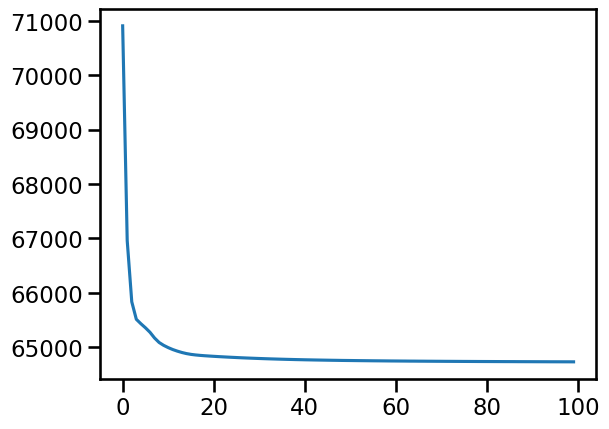

In [13]:
plt.plot(model.history['loss'])

In [14]:
model.calc_all_latent()

latent = model.get_all_latent()

In [15]:
if False:
    latent_barcode = np.array([_.split('~')[1] for _ in latent[1]])
    df_latent = pd.DataFrame(latent[0], index=latent_barcode)
    df_latent.to_csv(f'{out_dir}/res.csv')

else:
    df_latent = pd.read_csv(f'{out_dir}/res.csv', index_col=0)
    df_latent.index = df_latent.index.astype('str')

In [16]:
ad_db_rna.obsm['X_emb'] = df_latent.loc[ad_db_rna.obs_names, :].values
ad_sra50_rna.obsm['X_emb'] = df_latent.loc[ad_sra50_rna.obs_names, :].values
ad_sra100_rna.obsm['X_emb'] = df_latent.loc[ad_sra100_rna.obs_names, :].values
ad_sat.obsm['X_emb'] = df_latent.loc[ad_sat.obs_names, :].values

In [17]:
ad_mosaic = sc.concat([ad_db_rna, ad_sra50_rna, ad_sra100_rna, ad_sat])
# ad_mosaic = get_umap(ad_mosaic, ['X_emb'])

/home/yanxh/anaconda3/envs/multi-omics/lib/python3.8/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [21]:
anal_dir = '../../../results/embeddings/Cobolt/DBiT-RnaAtac-Atac'
os.makedirs(anal_dir, exist_ok=True)

In [22]:
df = pd.DataFrame(ad_mosaic.obsm['X_emb'], index=ad_mosaic.obs_names)
df.to_csv(join(anal_dir, 'df_emb.csv'))